# Stage 3 - Model Training
This notebook implements the exact SMOTE placement, CV strategy, tuning grids, and final model fitting rules from the pipeline.

In [1]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate, StratifiedShuffleSplit, ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

RANDOM_STATE = 42
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PLOT_DIR = BASE_DIR / 'outputs' / 'plots' / 'stage3'
MODEL_DIR = BASE_DIR / 'models'
PLOT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

def save_plot(name: str):
    path = PLOT_DIR / f'{name}.png'
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved plot: {path}')


## Load Stage 2 Outputs

In [2]:
with open(PROCESSED_DIR / 'stage2_outputs.pkl', 'rb') as f:
    stage2 = pickle.load(f)
X_train_eng = stage2['X_train_eng']
X_test_eng = stage2['X_test_eng']
y_train = stage2['y_train']
y_test = stage2['y_test']
print('Train/Test shapes:', X_train_eng.shape, X_test_eng.shape)
print('Class distribution train:', y_train.value_counts(normalize=True))


Train/Test shapes: (8000, 49) (2000, 49)
Class distribution train: defaulted
0    0.849875
1    0.150125
Name: proportion, dtype: float64


## CV and SMOTE Setup
Define shared fold object and scoring metrics. SMOTE is applied inside CV folds via `ImbPipeline`.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'] #accuracy = TP+TN/Total, precision = TP/TP+FP, recall = TP/TP+FN, f1 = 2*precision*recall/precision+recall, roc_auc = area under the curve of TPR vs FPR
#low precision = many false positives, low recall = many false negatives, low f1 = imbalance between precision and recall, low roc_auc = poor ranking of positive class
def evaluate_cv(model):
    pipe = ImbPipeline([('smote', SMOTE(random_state=RANDOM_STATE)), ('classifier', model)])
    return cross_validate(pipe, X_train_eng, y_train, cv=cv, scoring=scoring_metrics, n_jobs=-1, return_train_score=False)

def tune_grid(model_factory, param_grid):
    rows = []
    for params in ParameterGrid(param_grid):
        model = model_factory(**params)
        cv_result = evaluate_cv(model)
        rows.append({
            'params': params,
            'mean_roc_auc': float(np.mean(cv_result['test_roc_auc'])),
            'std_roc_auc': float(np.std(cv_result['test_roc_auc'])),
            'cv_result': cv_result
        })
    tuning_df = pd.DataFrame(rows).sort_values('mean_roc_auc', ascending=False).reset_index(drop=True)
    return tuning_df


## Model 1 - Logistic Regression (L2)
Tune C by CV ROC-AUC, then fit final model on full SMOTE-resampled training set.

Best C (L2): 1


d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Saved plot: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\outputs\plots\stage3\stage3_lr_l2_top15_coefficients.png


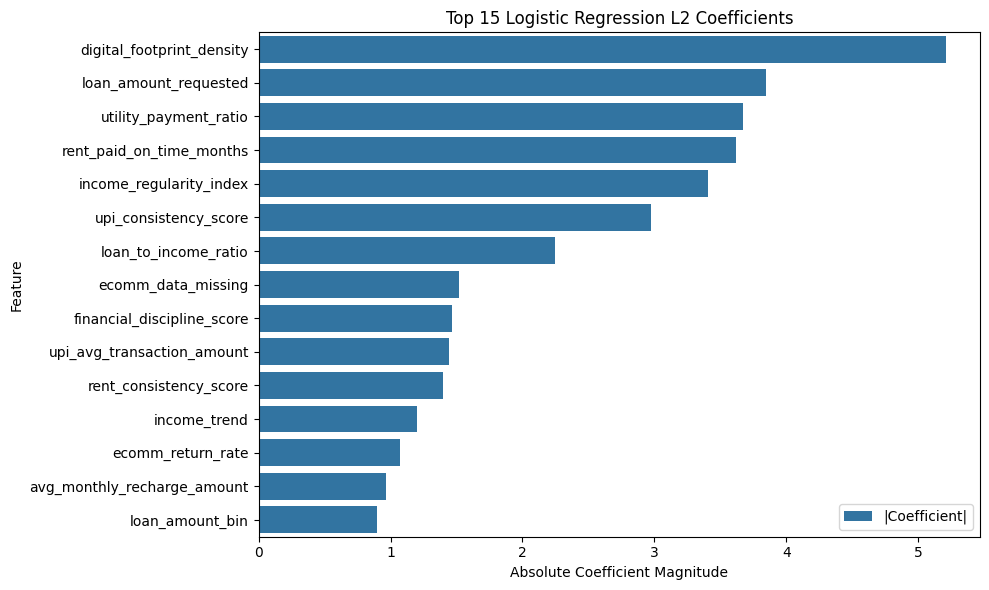

digital_footprint_density      5.208371
loan_amount_requested          3.848145
utility_payment_ratio          3.675622
rent_paid_on_time_months       3.616043
income_regularity_index        3.405604
upi_consistency_score          2.971694
loan_to_income_ratio           2.243852
ecomm_data_missing             1.518850
financial_discipline_score     1.466886
upi_avg_transaction_amount     1.446405
rent_consistency_score         1.394598
income_trend                   1.198439
ecomm_return_rate              1.073009
avg_monthly_recharge_amount    0.967436
loan_amount_bin                0.896318
dtype: float64


In [4]:
c_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
l2_tuning = tune_grid(lambda C: LogisticRegression(C=C, penalty='l2', solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE), c_grid)
best_c_l2 = l2_tuning.loc[0, 'params']['C']
print('Best C (L2):', best_c_l2)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_eng, y_train)
lr_l2 = LogisticRegression(C=best_c_l2, penalty='l2', solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE)
lr_l2.fit(X_train_sm, y_train_sm)

coef_abs = pd.Series(np.abs(lr_l2.coef_[0]), index=X_train_eng.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 6))
sns.barplot(x=coef_abs.values, y=coef_abs.index, label='|Coefficient|')
plt.title('Top 15 Logistic Regression L2 Coefficients')
plt.xlabel('Absolute Coefficient Magnitude')
plt.ylabel('Feature')
plt.legend()
save_plot('stage3_lr_l2_top15_coefficients')
plt.show()
print(coef_abs)


## Model 2 - Logistic Regression (L1)
Tune C, fit final model, and report sparsity (number of zero coefficients).

In [5]:
l1_tuning = tune_grid(lambda C: LogisticRegression(C=C, penalty='l1', solver='liblinear', max_iter=1000, random_state=RANDOM_STATE), c_grid)
best_c_l1 = l1_tuning.loc[0, 'params']['C']
print('Best C (L1):', best_c_l1)
lr_l1 = LogisticRegression(C=best_c_l1, penalty='l1', solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)
lr_l1.fit(X_train_sm, y_train_sm)
l1_zero_count = int(np.sum(lr_l1.coef_[0] == 0))
l2_zero_count = int(np.sum(lr_l2.coef_[0] == 0))
print('L1 zero coefficients:', l1_zero_count)
print('L2 zero coefficients:', l2_zero_count)


Best C (L1): 0.1


d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


L1 zero coefficients: 17
L2 zero coefficients: 0


## Model 3 - Naive Bayes
Train GaussianNB with fold-wise SMOTE in CV and final fit on SMOTE-resampled full training data.

In [6]:
nb_cv = evaluate_cv(GaussianNB())
nb_model = GaussianNB()
nb_model.fit(X_train_sm, y_train_sm)
print('Naive Bayes CV ROC-AUC mean:', np.mean(nb_cv['test_roc_auc']))
print('Note: Feature independence assumption is likely violated for this dataset.')


Naive Bayes CV ROC-AUC mean: 0.8907811745553424
Note: Feature independence assumption is likely violated for this dataset.


## Model 4 - KNN
Tune n_neighbors, fit final KNN, and note scale sensitivity plus dimensionality constraints.

In [7]:
knn_tuning = tune_grid(lambda n_neighbors: KNeighborsClassifier(n_neighbors=n_neighbors, metric='minkowski'), {'n_neighbors': [3, 5, 7, 9, 11, 15, 21]})
best_k_knn = knn_tuning.loc[0, 'params']['n_neighbors']
knn_model = KNeighborsClassifier(n_neighbors=best_k_knn, metric='minkowski')
knn_model.fit(X_train_sm, y_train_sm)
print('Best K (KNN):', best_k_knn)
print('Normalization from Stage 1 already applied. High dimensionality may still dilute neighborhood distance quality.')


Best K (KNN): 21
Normalization from Stage 1 already applied. High dimensionality may still dilute neighborhood distance quality.


## Model 5 - Decision Tree (Overfit and Tuned)
Fit an overfit baseline and a tuned variant; keep tuned variant for Stage 4 main evaluation.

In [8]:
dt_overfit = DecisionTreeClassifier(criterion='gini', max_depth=None, random_state=RANDOM_STATE)
dt_overfit.fit(X_train_sm, y_train_sm)
train_acc_overfit = dt_overfit.score(X_train_sm, y_train_sm)
test_acc_overfit = dt_overfit.score(X_test_eng, y_test)
print('DT-overfit train accuracy:', train_acc_overfit)
print('DT-overfit test accuracy:', test_acc_overfit)

dt_tuning = tune_grid(
    lambda max_depth, criterion: DecisionTreeClassifier(max_depth=max_depth, criterion=criterion, random_state=RANDOM_STATE),
    {'max_depth': [3, 5, 7, 10, 15], 'criterion': ['gini', 'entropy']}
)
best_dt_params = dt_tuning.loc[0, 'params']
dt_tuned = DecisionTreeClassifier(**best_dt_params, random_state=RANDOM_STATE)
dt_tuned.fit(X_train_sm, y_train_sm)
print('Best DT params:', best_dt_params)


DT-overfit train accuracy: 1.0
DT-overfit test accuracy: 0.822
Best DT params: {'criterion': 'entropy', 'max_depth': 5}


## Model 6 - Random Forest
Tune and fit final random forest on full SMOTE training set.

In [9]:
rf_tuning = tune_grid(
    lambda n_estimators, max_depth, min_samples_split: RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split, random_state=RANDOM_STATE, n_jobs=-1
    ),
    {'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5]}
)
best_rf_params = rf_tuning.loc[0, 'params']
rf_model = RandomForestClassifier(**best_rf_params, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train_sm, y_train_sm)
print('Best RF params:', best_rf_params)


Best RF params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 300}


## Model 7 - XGBoost
Tune and fit final XGBoost model using specified hyperparameter search space.

In [10]:
xgb_tuning = tune_grid(
    lambda n_estimators, max_depth, learning_rate, subsample: XGBClassifier(
        n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate, subsample=subsample,
        use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE
    ),
    {'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2], 'subsample': [0.8, 1.0]}
)
best_xgb_params = xgb_tuning.loc[0, 'params']
xgb_model = XGBClassifier(**best_xgb_params, use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)
xgb_model.fit(X_train_sm, y_train_sm)
print('Best XGB params:', best_xgb_params)


Best XGB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}


d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:34:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Model 8 - SVM
Train on a stratified 3000-row subsample of SMOTE-resampled training data and tune C/kernel.

In [11]:
svm_sample_size = 3000
sss = StratifiedShuffleSplit(n_splits=1, train_size=svm_sample_size, random_state=RANDOM_STATE)
svm_idx, _ = next(sss.split(X_train_sm, y_train_sm))
X_svm = X_train_sm.iloc[svm_idx]
y_svm = y_train_sm.iloc[svm_idx]
print('SVM sample shape:', X_svm.shape)

svm_rows = []
for params in ParameterGrid({'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}):
    svm = SVC(C=params['C'], kernel=params['kernel'], probability=True, random_state=RANDOM_STATE)
    cv_result = cross_validate(svm, X_svm, y_svm, cv=cv, scoring=scoring_metrics, n_jobs=-1)
    svm_rows.append({'params': params, 'mean_roc_auc': float(np.mean(cv_result['test_roc_auc'])), 'cv_result': cv_result})
svm_tuning = pd.DataFrame(svm_rows).sort_values('mean_roc_auc', ascending=False).reset_index(drop=True)
best_svm_params = svm_tuning.loc[0, 'params']
svm_model = SVC(C=best_svm_params['C'], kernel=best_svm_params['kernel'], probability=True, random_state=RANDOM_STATE)
svm_model.fit(X_svm, y_svm)
print('Best SVM params:', best_svm_params)


SVM sample shape: (3000, 49)
Best SVM params: {'C': 10, 'kernel': 'rbf'}


## Build CV Summary Table
Aggregate mean and std metrics for all models from fold-wise CV results.

In [12]:
cv_results_map = {
    'LR_L2': l2_tuning.loc[0, 'cv_result'],
    'LR_L1': l1_tuning.loc[0, 'cv_result'],
    'NaiveBayes': nb_cv,
    'KNN': knn_tuning.loc[0, 'cv_result'],
    'DecisionTree_Tuned': dt_tuning.loc[0, 'cv_result'],
    'RandomForest': rf_tuning.loc[0, 'cv_result'],
    'XGBoost': xgb_tuning.loc[0, 'cv_result'],
    'SVM': svm_tuning.loc[0, 'cv_result'],
}

rows = []
for model_name, result in cv_results_map.items():
    rows.append({
        'model': model_name,
        'accuracy_mean': np.mean(result['test_accuracy']), 'accuracy_std': np.std(result['test_accuracy']),
        'precision_mean': np.mean(result['test_precision']), 'precision_std': np.std(result['test_precision']),
        'recall_mean': np.mean(result['test_recall']), 'recall_std': np.std(result['test_recall']),
        'f1_mean': np.mean(result['test_f1']), 'f1_std': np.std(result['test_f1']),
        'roc_auc_mean': np.mean(result['test_roc_auc']), 'roc_auc_std': np.std(result['test_roc_auc']),
    })
cv_summary = pd.DataFrame(rows).sort_values('roc_auc_mean', ascending=False)
print(cv_summary)


                model  accuracy_mean  accuracy_std  precision_mean  \
7                 SVM       0.895667      0.006549        0.866008   
1               LR_L1       0.847625      0.008637        0.496294   
0               LR_L2       0.852625      0.010258        0.506289   
6             XGBoost       0.883250      0.003245        0.592089   
5        RandomForest       0.869250      0.008153        0.546731   
2          NaiveBayes       0.785250      0.005884        0.398534   
4  DecisionTree_Tuned       0.810125      0.008789        0.430369   
3                 KNN       0.741500      0.013203        0.355159   

   precision_std  recall_mean  recall_std   f1_mean    f1_std  roc_auc_mean  \
7       0.017094     0.937333    0.028079  0.899745  0.007305      0.954184   
1       0.017259     0.838489    0.014008  0.623226  0.012119      0.926977   
0       0.020929     0.840985    0.016740  0.631791  0.017769      0.926705   
6       0.011503     0.717794    0.037396  0.648258  

## Save Stage 3 Outputs
Persist all trained models, CV summary, and best hyperparameters.

In [13]:
models = {
    'lr_l2': lr_l2,
    'lr_l1': lr_l1,
    'naive_bayes': nb_model,
    'knn': knn_model,
    'decision_tree_overfit': dt_overfit,
    'decision_tree_tuned': dt_tuned,
    'random_forest': rf_model,
    'xgboost': xgb_model,
    'svm': svm_model,
}
for name, model in models.items():
    with open(MODEL_DIR / f'{name}.pkl', 'wb') as f:
        pickle.dump(model, f)

stage3_output = {
    **stage2,
    'models': models,
    'cv_summary': cv_summary,
    'best_params': {
        'lr_l2': {'C': best_c_l2},
        'lr_l1': {'C': best_c_l1},
        'knn': {'n_neighbors': best_k_knn},
        'decision_tree_tuned': best_dt_params,
        'random_forest': best_rf_params,
        'xgboost': best_xgb_params,
        'svm': best_svm_params,
    },
    'dt_overfit_train_acc': train_acc_overfit,
    'dt_overfit_test_acc': test_acc_overfit,
}
out_path = PROCESSED_DIR / 'stage3_outputs.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(stage3_output, f)
print('Saved:', out_path)


Saved: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\data\processed\stage3_outputs.pkl


## Stage 3 Summary

In [14]:
print('=' * 70)
print('STAGE 3 SUMMARY')
print('- Trained and stored all required models with proper SMOTE placement.')
print(f"- CV table rows: {cv_summary.shape[0]}")
print(f"- Best CV ROC-AUC model: {cv_summary.iloc[0]['model']}")
print(f"- DT overfit train/test accuracy: {train_acc_overfit:.4f} / {test_acc_overfit:.4f}")
print(f"- Saved outputs to: {out_path}")
print('=' * 70)


STAGE 3 SUMMARY
- Trained and stored all required models with proper SMOTE placement.
- CV table rows: 8
- Best CV ROC-AUC model: SVM
- DT overfit train/test accuracy: 1.0000 / 0.8220
- Saved outputs to: d:\College\Sem-4\ML\Course Project\cursor-alt-cred-score\data\processed\stage3_outputs.pkl
